# US Flight Delays Based on the Day of the Week
**Author: Thendo Nemakonde**

## Analysis: The Impact of the Day of the Week on Departure Delays
**Objective:** Determine which specific days of the week experience a higher frequency departure delay.

### Business Questions Addressed 
* Which day of the week is historically the most prone to departure delays?
* What is the baseline probability of experiencing a delay depending on the day you choose to fly?
* How does the average delay duration fluctuate throughout the standard 7-day week?

### Methodology
1. **Target Variable Definition:** Create a binary indicator for delayed vs on-time flights.
2. **Aggregation:** Group departure data by the day of the week to calculate delay likelihood.
3. **Visualization:** Plot the delay percentage to identify weekly operational trends and bottlenecks.

### Core Libraries
- Pandas
- Matplotlib

In [1]:
#importing libraries to be used:
import pandas as pd
import matplotlib.pyplot as plt

flights = pd.read_csv('flights_dataset.csv')
flights

,scheduled,actual,carrier,flight,tailnum,origin,dest,air_time,distance
0,"04/29/2023, 16:35","04/29/2023, 17:01",WN,1079,N230WN,ATL,HOU,110.0,696
1,"07/02/2023, 15:10","07/02/2023, 15:05",DL,355,N953AT,ATL,GPT,54.0,352
2,"12/25/2023, 10:55","12/25/2023, 10:53",WN,291,N413WN,ATL,RDU,57.0,356
3,"09/01/2023, 12:50","09/01/2023, 12:48",DL,1132,N947DZ,ATL,TYS,28.0,152
4,"12/14/2023, 07:05","12/14/2023, 07:02",DL,40,N332DN,ATL,BOS,121.0,946
...,...,...,...,...,...,...,...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17",WN,13,N400WN,ATL,MCO,63.0,404
4996,"04/09/2023, 19:50","04/09/2023, 19:58",OH,1320,N567NN,ATL,CLT,42.0,226
4997,"12/14/2023, 13:20","12/14/2023, 13:16",DL,695,N363NB,ATL,DAL,103.0,721
4998,"12/06/2023, 13:05","12/06/2023, 13:01",DL,911,N992AT,ATL,GSO,56.0,306


In [2]:
#Exploratory Data Analysis:
#using 'scheduled' and 'actual' columns for our analysis

departures = flights[['scheduled', 'actual']]
departures 

,scheduled,actual
0,"04/29/2023, 16:35","04/29/2023, 17:01"
1,"07/02/2023, 15:10","07/02/2023, 15:05"
2,"12/25/2023, 10:55","12/25/2023, 10:53"
3,"09/01/2023, 12:50","09/01/2023, 12:48"
4,"12/14/2023, 07:05","12/14/2023, 07:02"
...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17"
4996,"04/09/2023, 19:50","04/09/2023, 19:58"
4997,"12/14/2023, 13:20","12/14/2023, 13:16"
4998,"12/06/2023, 13:05","12/06/2023, 13:01"


In [3]:
#Finding the datatypes of each column
departures.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   scheduled  5000 non-null   str  
 1   actual     5000 non-null   str  
dtypes: str(2)
memory usage: 78.3 KB


In [4]:
#Data cleaning
#Now we convert the "str' - String datatype to datetime to enable time-date delta arithmetic for delay durations
departures['scheduled'] = pd.to_datetime(departures['scheduled'])
departures['actual'] = pd.to_datetime(departures['actual'])
departures.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   scheduled  5000 non-null   datetime64[us]
 1   actual     5000 non-null   datetime64[us]
dtypes: datetime64[us](2)
memory usage: 78.3 KB


In [5]:
#Calculating the delay using formula: delay = actual - scheduled
departures['delays'] = departures.eval('actual - scheduled')
departures

,scheduled,actual,delays
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00
...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00


In [6]:
#Flights are considered late when they depart more than 15 minutes (900 seconds) later
#Calculating how flights were late (or early)
departures['flight_is_late'] = departures['delays'].dt.total_seconds() > 900
departures

,scheduled,actual,delays,flight_is_late
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00,True
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00,False
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00,False
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00,False
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00,False
...,...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00,False
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00,False
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00,False
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00,False


In [7]:
#Finding the days of the week that the flights 'actually' took place
departures['day_of_week'] = departures['actual'].dt.strftime('%a')
departures

,scheduled,actual,delays,flight_is_late,day_of_week
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00,True,Sat
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00,False,Sun
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00,False,Mon
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00,False,Fri
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00,False,Thu
...,...,...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00,False,Wed
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00,False,Sun
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00,False,Thu
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00,False,Wed


In [8]:
#Calculating the percentage of flights that are delayed for each day of the week grouped by the day of the week
#finding the mean of 'flight_is_late' column will help find the percentage
# key: perc = percenatge
delayed_avg = departures.groupby('day_of_week')['flight_is_late'].mean()
perc_of_delayed = delayed_avg * 100
perc_of_delayed

day_of_week
Fri    22.593583
Mon    20.185923
Sat    18.558282
Sun    23.376623
Thu    20.939597
Tue    15.419847
Wed    16.691285
Name: flight_is_late, dtype: float64

In [9]:
#Data results came back in alphabetical order, so the data has to be reordered to standard days of the week format
index_order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
perc_of_delayed = perc_of_delayed.reindex(index_order)
perc_of_delayed

day_of_week
Sun    23.376623
Mon    20.185923
Tue    15.419847
Wed    16.691285
Thu    20.939597
Fri    22.593583
Sat    18.558282
Name: flight_is_late, dtype: float64

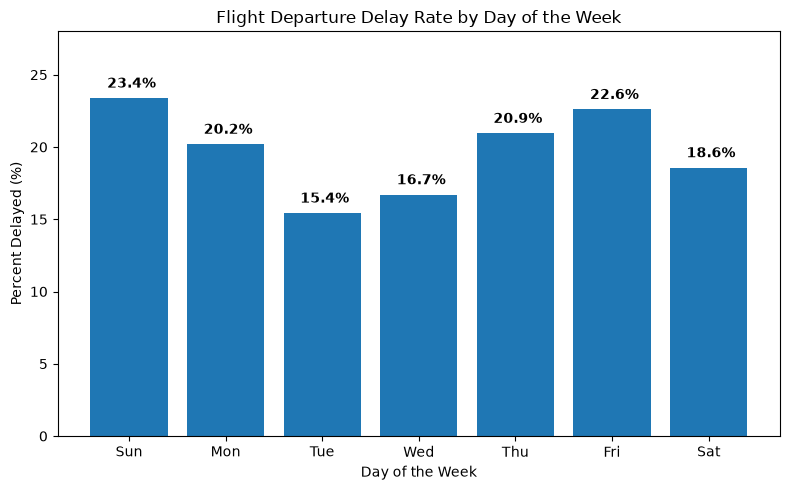

In [10]:
#Data visualization
#Plotting Bar graph of Percent delayed over Day of the week
plt.figure(figsize = (8, 5))
bars = plt.bar(perc_of_delayed.index, perc_of_delayed)
plt.title("Flight Departure Delay Rate by Day of the Week")
plt.xlabel('Day of the Week')
plt.ylabel('Percent Delayed (%)')
plt.ylim(0, 28)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.5, f'{height: .1f}%',
             ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold')
plt.tight_layout()
plt.show()      

## Visual insights
The data visually shows that Sunday with 23.4% and Friday with 22.6% are the days that has the highest-risk of delayed flights while Tuesday 15.4% is the most reliable day.

In [12]:
#Bringing in essential columns from the original flights dataframe
departures['carrier'] = flights['carrier']
departures['origin'] = flights['origin']
departures['dest'] = flights['dest']
departures['distance'] = flights['distance']

#Exporting the updated dataset to CSV for Power BI data visualization
departures.to_csv('Cleaned_US_flights.csv', index = False)

departures

,scheduled,actual,delays,flight_is_late,day_of_week,carrier,origin,dest,distance
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00,True,Sat,WN,ATL,HOU,696
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00,False,Sun,DL,ATL,GPT,352
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00,False,Mon,WN,ATL,RDU,356
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00,False,Fri,DL,ATL,TYS,152
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00,False,Thu,DL,ATL,BOS,946
...,...,...,...,...,...,...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00,False,Wed,WN,ATL,MCO,404
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00,False,Sun,OH,ATL,CLT,226
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00,False,Thu,DL,ATL,DAL,721
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00,False,Wed,DL,ATL,GSO,306
